In [2]:
import numpy as np
import matplotlib.pyplot as plt
# import ipympl
import imageio.v3 as iio
import skimage.color
import skimage.filters
import skimage.measure


In [3]:
def connected_components(filename, sigma=1.0, t=0.5, connectivity=2):
    # load the image
    image = iio.imread(filename)
    # convert the image to grayscale
    gray_image = skimage.color.rgb2gray(image)
    # denoise the image with a Gaussian filter
    blurred_image = skimage.filters.gaussian(gray_image, sigma=sigma)
    # mask the image according to threshold
    binary_mask = blurred_image < t
    # perform connected component analysis
    labeled_image, count = skimage.measure.label(binary_mask,
                                                 connectivity=connectivity, return_num=True)
    return labeled_image, count


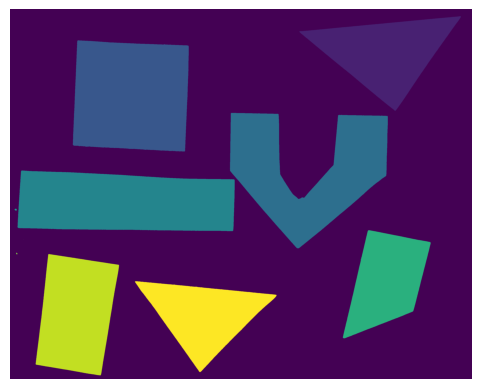

In [4]:
labeled_image, count = connected_components(filename="./photos/shapes-01.jpg", sigma=2.0, t=0.9, connectivity=2)
fig, ax = plt.subplots()
plt.imshow(labeled_image)
plt.axis("off")
plt.show()


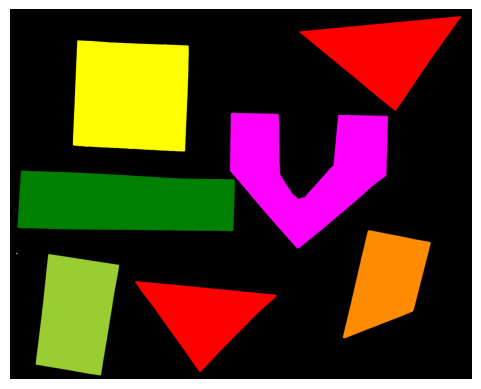

In [5]:
# convert the label image to color image
colored_label_image = skimage.color.label2rgb(labeled_image, bg_label=0)
fig, ax = plt.subplots()
plt.imshow(colored_label_image)
plt.axis("off")
plt.show()


In [6]:
print("Found", count, "objects in the image.")
# or
# num_objects = np.max(labeled_image)
# print("Found", num_objects, "objects in the image.")


Found 11 objects in the image.


In [7]:
# compute object features and extract object areas
object_features = skimage.measure.regionprops(labeled_image)
object_areas = [objf["area"] for objf in object_features]
object_areas


[np.float64(318542.0),
 np.float64(1.0),
 np.float64(523204.0),
 np.float64(496613.0),
 np.float64(517331.0),
 np.float64(143.0),
 np.float64(256215.0),
 np.float64(1.0),
 np.float64(68.0),
 np.float64(338784.0),
 np.float64(265755.0)]

In [8]:
min_area = 200
object_areas = np.array([objf["area"] for objf in object_features])
# object_labels = np.array([objf["label"] for objf in object_features])
# large_objects = object_labels[object_areas > min_area]
# print("Found", len(large_objects), "objects!")
# or
n = np.count_nonzero(object_areas > min_area)
print("Found", n, "objects!")


Found 7 objects!


(np.float64(-0.5), np.float64(3067.5), np.float64(2456.5), np.float64(-0.5))

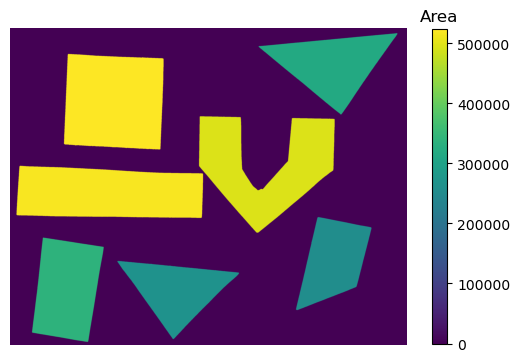

In [9]:
object_areas = np.array([objf["area"] for objf in skimage.measure.regionprops(labeled_image)])
object_areas = np.insert(0,1,object_areas)
colored_area_image = object_areas[labeled_image]
fig, ax = plt.subplots()
im = plt.imshow(colored_area_image)
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.ax.set_title("Area")
plt.axis("off")


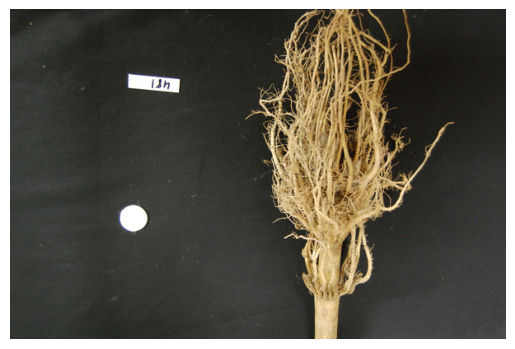

In [10]:
maize_roots = plt.imread('./photos/maize-root-cluster.jpg')

fig, ax = plt.subplots()
plt.imshow(maize_roots)
plt.axis("off")
plt.show()


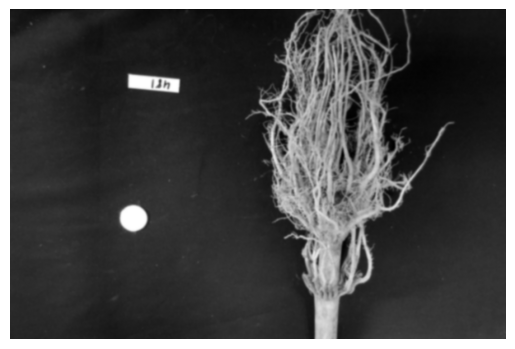

Found automatic threshold t = 0.41133424639701843.
<class 'numpy.ndarray'>
float32
(400, 602)
0.061068922 1.0


In [24]:
from skimage import io, filters, color

gray = color.rgb2gray(maize_roots)  
blurred_image = filters.gaussian(gray, sigma=1)
blurred_image = blurred_image.astype(np.float32)
plt.imshow(blurred_image, cmap="gray")
plt.axis("off")
plt.show()
t = filters.threshold_otsu(blurred_image)
print("Found automatic threshold t = {}.".format(t))
print(type(blurred_image))
print(blurred_image.dtype)
print(blurred_image.shape)
print(np.min(blurred_image), np.max(blurred_image))

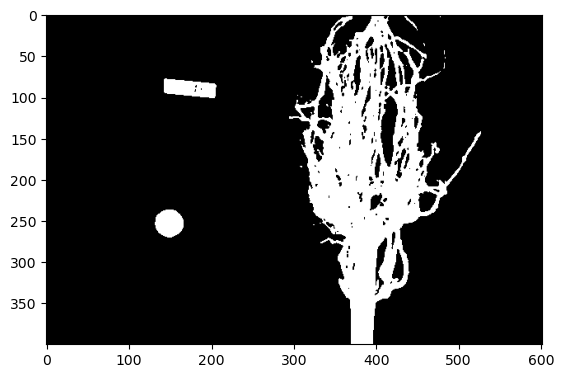

In [25]:
# create a binary mask with the threshold found by Otsu's method
binary_mask = blurred_image > t

fig, ax = plt.subplots()
plt.imshow(binary_mask, cmap="gray")


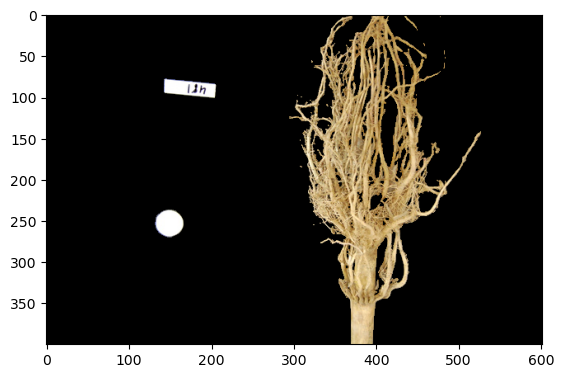

In [26]:
# apply the binary mask to select the foreground
selection = maize_roots.copy()
selection[~binary_mask] = 0

fig, ax = plt.subplots()
plt.imshow(selection)


In [27]:
def measure_root_mass(filename, sigma=1.0):
    # read the original image, converting to grayscale on the fly
    image = iio.imread(uri=filename, mode="L") # “L” = automatic convert to gray
    # blur before thresholding
    blurred_image = skimage.filters.gaussian(image, sigma=sigma)
    # perform automatic thresholding to produce a binary image
    t = skimage.filters.threshold_otsu(blurred_image)
    binary_mask = blurred_image > t
    # determine root mass ratio
    rootPixels = np.count_nonzero(binary_mask)
    w = binary_mask.shape[1]
    h = binary_mask.shape[0]
    density = rootPixels / (w * h)
    return density


In [29]:
measure_root_mass(filename='./photos/maize-root-cluster.jpg', sigma=1.5)
import glob

all_files = glob.glob("data/trial-*.jpg")
for filename in all_files:
    density = measure_root_mass(filename=filename, sigma=1.5)
    # output in format suitable for .csv
    print(filename, density, sep=",")
